In [76]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import plotly.express as px
import matplotlib.pyplot as plt

### **Get & Preprocess Data**

We first try to investigate the date from the project, then we will moove to the real high frequency data.

#### 1. Project data

We can make the following remarks:
- there's a lot of time points, some times we find several prices for the same time, which seems confusing
- the log prices are discrete, they take only some specific value
- the log returns distributions has fat tails
  

In [3]:
Full_df = pd.DataFrame()
for i in range(21,35):
    df = pd.read_csv(f'data/out{i}.csv')
    Full_df = pd.concat([Full_df,df])

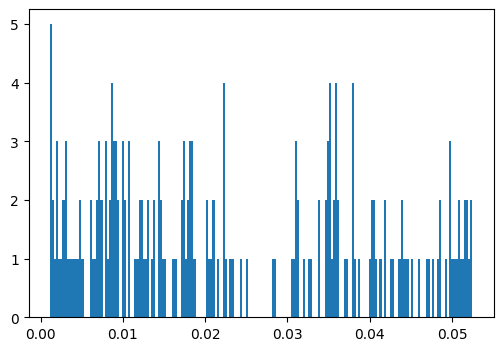

In [105]:
df_d1 = Full_df[Full_df['day']==1].copy()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df_d1.reset_index()['tick'].iloc[:200],bins = 200)
plt.show()

there's multiple log prices for the same tick, and no 

In [60]:

df_d1 = (
    df_d1.sort_values('tick').reset_index()
    .drop(columns='index')
    .set_index('tick')
    .assign(price=lambda df : np.exp(df['logprice']))
    .assign(logreturn=lambda df : df['logprice'].diff())
    .assign(RV = lambda df: df['logreturn']
)


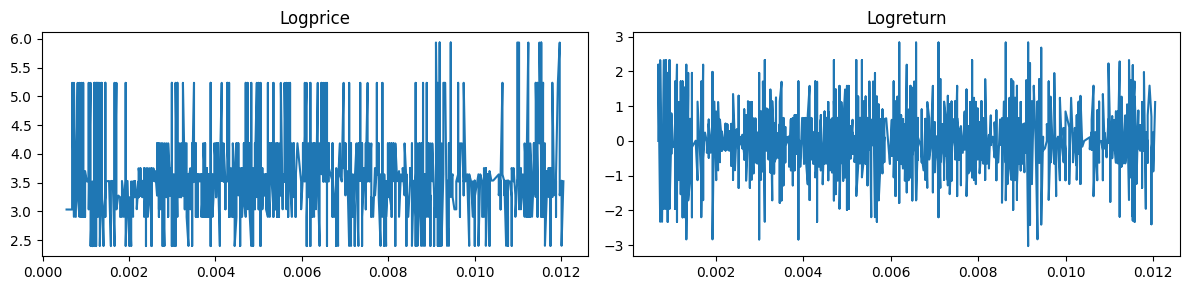

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Left subplot
axes[0].plot(df_d1[['logprice']].iloc[:1000])
axes[0].set_title("Logprice")

# Right subplot
axes[1].plot(df_d1['logreturn'].iloc[:1000])
axes[1].set_title("Logreturn")

plt.tight_layout()
plt.show()

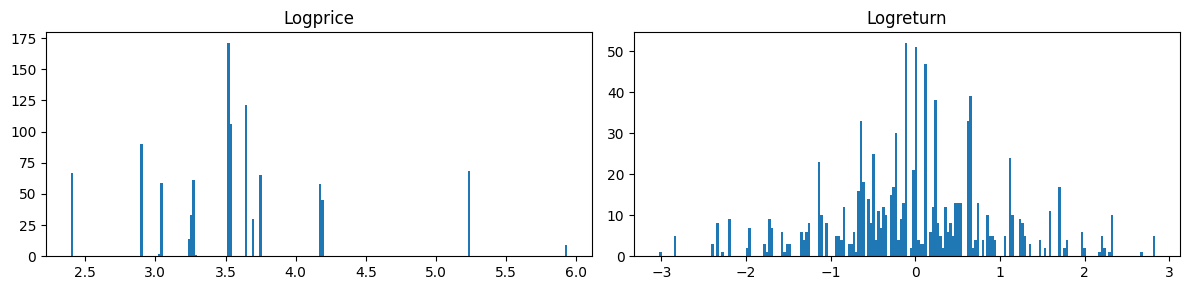

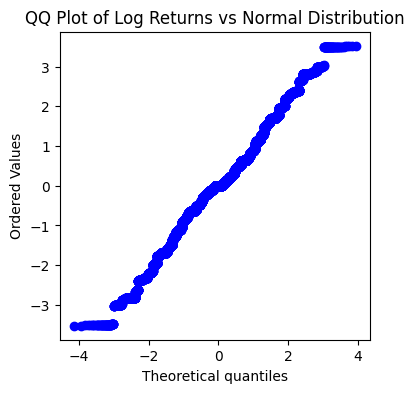

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Left subplot
axes[0].hist(df_d1[['logprice']].iloc[:1000],bins=200)
axes[0].set_title("Logprice")

# Right subplot
axes[1].hist(df_d1['logreturn'].iloc[:1000],bins=200)
axes[1].set_title("Logreturn")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(df_d1['logreturn'], dist="norm", plot=ax)
ax.set_title('QQ Plot of Log Returns vs Normal Distribution')
plt.show()


#### 2. LOBSTER Data

We know take some real high frequency market data, especially the foster dataset for MSFT prices on the 2012-06-21 day.

In [261]:
# Data Import
columns_ob = ['Ask','AskVolume','Bid','BidVolume']
df_ob = pd.read_csv('data/AMZN_2012-06-21_34200000_57600000_orderbook_1.csv',header=None,sep=';')
df_ob.columns = columns_ob

df_desc = pd.read_csv('data/AMZN_2012-06-21_34200000_57600000_message_1.csv',header=None)
df_desc.columns = ['Time','Type','OrderID','Size','Price','Direction']

raw_data = pd.concat([df_ob,df_desc],axis=1)
raw_data.head()

,Ask,AskVolume,Bid,BidVolume,Time,Type,OrderID,Size,Price,Direction
0,2239500,100,2231800,100,34200.017460,5,0,1,2238200,-1
1,2239500,100,2238100,21,34200.189608,1,11885113,21,2238100,1
2,2239500,100,2237500,100,34200.190226,4,11885113,21,2238100,1
3,2239500,100,2237500,74,34200.190226,4,11534792,26,2237500,1
4,2239500,100,2237500,74,34200.372780,5,0,100,2238400,-1


In [262]:
# Processing
data = ( 
    raw_data.copy()
    .assign(Ask=lambda df : df['Ask']/10000)
    .assign(Bid=lambda df : df['Bid']/10000)
    .assign(mid=lambda df : (df['Ask']+df['Bid'])/2)
    .assign(logprice=lambda df : np.log(df['mid']))    
    .assign(logret=lambda df : df['logprice'].diff())    
    .assign(spread=lambda df : df['Ask']-df['Bid'])
    .assign(volumespread=lambda df : df['AskVolume']-df['BidVolume'])
)    

### **First Data Visualisation**

Variable descriptions:
- Bid, Ask,
- Prices (=mid price at first approx), log prices
- log returns : comparison with normal distribution
- Volume, BidVolume & AskVolume


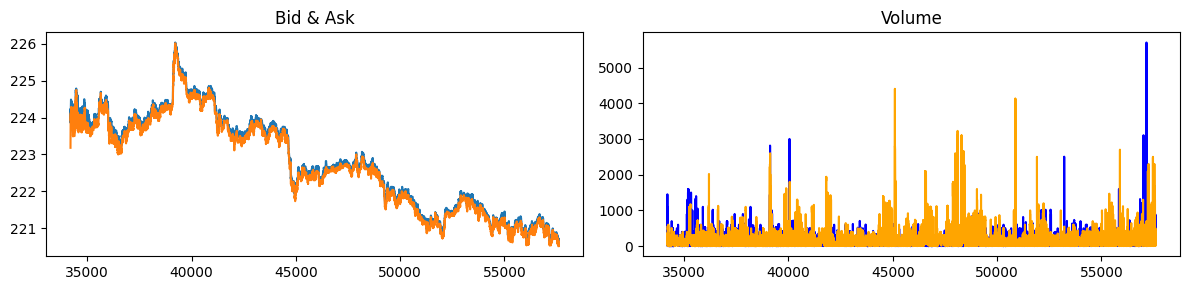

In [237]:
# First Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Left subplot
axes[0].plot(data['Time'],data['Ask'])
axes[0].plot(data['Time'],data['Bid'])
axes[0].set_title("Bid & Ask")

# Right subplot
axes[1].plot(data['Time'],data['AskVolume'],color='blue')
axes[1].plot(data['Time'],data['BidVolume'],color='orange')
axes[1].set_title("Volume")

plt.tight_layout()
plt.show()

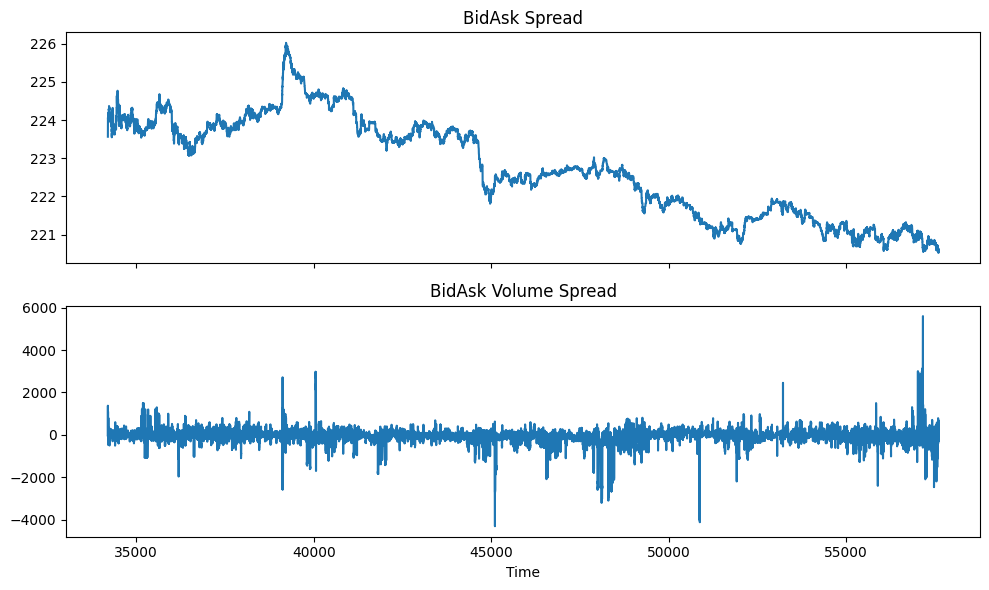

In [241]:
# first microstructure insights
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,6))

axes[0].plot(data['Time'], data['mid'])
axes[0].set_title('BidAsk Spread')

axes[1].plot(data['Time'], data['volumespread'])
axes[1].set_title('BidAsk Volume Spread')

plt.xlabel('Time')          # shared x-axis
plt.tight_layout()
plt.show()

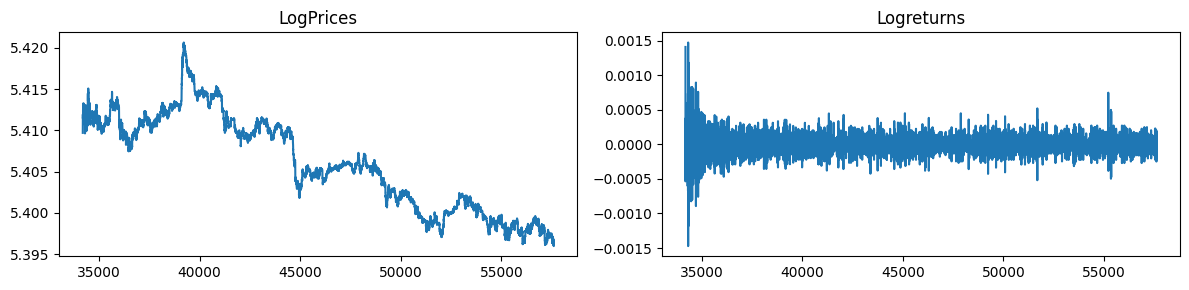

In [246]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Left subplot
axes[0].plot(data['Time'], data[['logprice']])
axes[0].set_title("LogPrices")

# Right subplot
axes[1].plot(data['Time'], data['logret'])
axes[1].set_title("Logreturns")

plt.tight_layout()
plt.show()

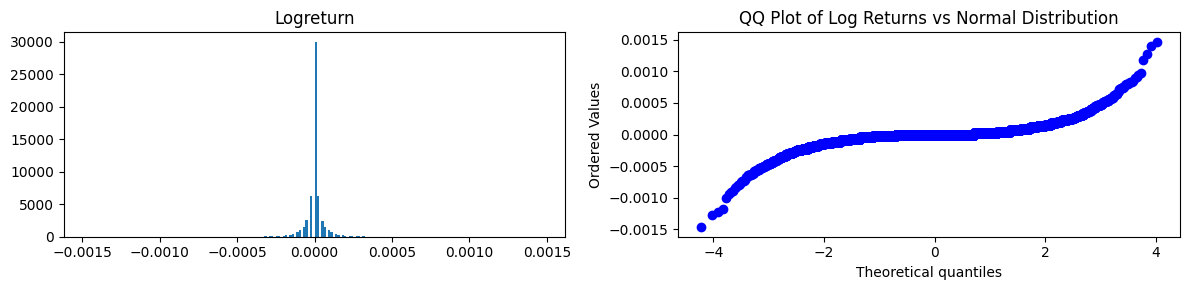

In [240]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].hist(data['logret'],bins=200)
axes[0].set_title("Logreturn")

stats.probplot(data['logret'], dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot of Log Returns vs Normal Distribution')
plt.tight_layout()
plt.show()


### **No Noise modelling**

Let's assume the data has no microstructure (ie. no noise modelisation), and compute:
- realized variance
- spot volatility

#### Realized Variance

In [299]:
def vwap(df):
    '''
    Compute Vwap price
    '''
    return (df['Ask']*df['AskVolume'] + df['Bid']*df['BidVolume']).sum()/max((df['AskVolume']+df['BidVolume']).sum(),1)

def RV(data,T):
    '''
    Comppute Realized variance depending on sampling frequency
    data (pd.DataFrame) - price data
    T (int) - sampling period in second
    '''
    data['Time'] = pd.to_datetime(data['Time'], unit='s')
    resampled_prices = data.set_index('Time').resample(f'{T}s').apply(vwap)
    resampled_prices = resampled_prices[resampled_prices != 0]
    logret = np.log(resampled_prices).diff()
    RV = (logret**2).sum()
    return RV*100

In [345]:
RV_res = pd.read_excel('res\RV_res.xlsx',index_col=0)

#RV_res = []
#for i in range(1, 10, 1):
#    RV_res.append({'T_Sampling': i, 'RV': RV(data, i)})
#for i in range(10, 600, 10):
#    RV_res.append({'T_Sampling': i, 'RV': RV(data, i)})
#RV_res = pd.DataFrame(RV_res)

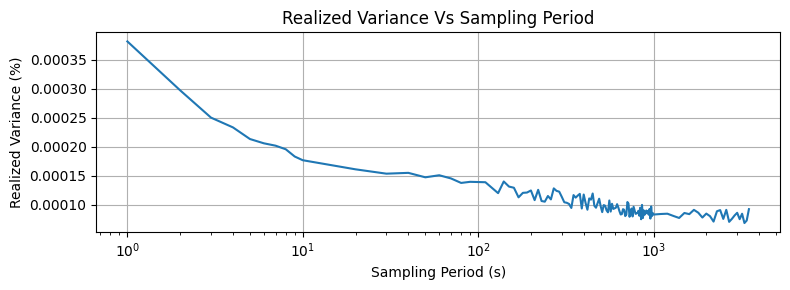

In [346]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogx(RV_res['T_Sampling'],RV_res['RV'])
ax.grid()
ax.set_xlabel('Sampling Period (s)')
ax.set_ylabel('Realized Variance (%)')
ax.set_title("Realized Variance Vs Sampling Period")
plt.tight_layout()
plt.show()